
Raster files found: 238

Cropland mask loaded & reprojected: cropland_mask.tif
  Mask shape       : (133, 171)  (matches WB rasters)
  Cropland pixels  : 5,338
  Non-cropland     : 17,405

Reading WB_1991_03.tif
  1991_03  MIN = -173.9188  MAX = -92.3577  MEAN = -125.9656

Reading WB_1991_04.tif
  1991_04  MIN = -201.4000  MAX = -67.2818  MEAN = -147.1827

Reading WB_1991_05.tif
  1991_05  MIN = -237.6267  MAX = -91.9437  MEAN = -165.5975

Reading WB_1991_06.tif
  1991_06  MIN = -45.3548  MAX = 179.5796  MEAN = 36.2513

Reading WB_1991_07.tif
  1991_07  MIN = 104.7689  MAX = 651.8738  MEAN = 309.0665

Reading WB_1991_08.tif
  1991_08  MIN = 65.6556  MAX = 507.3445  MEAN = 269.7766

Reading WB_1991_09.tif
  1991_09  MIN = -66.0692  MAX = 276.5490  MEAN = 112.6678

Reading WB_1992_03.tif
  1992_03  MIN = -182.8000  MAX = -134.5926  MEAN = -156.0903

Reading WB_1992_04.tif
  1992_04  MIN = -200.3351  MAX = -108.5921  MEAN = -155.3752

Reading WB_1992_05.tif
  1992_05  MIN = -249.5000  MA

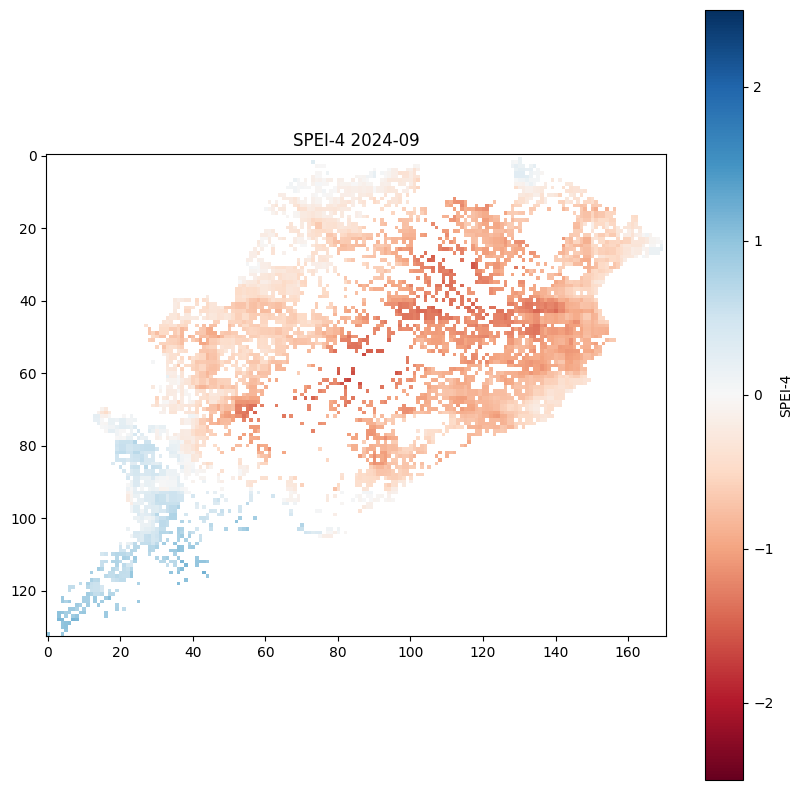


DONE.


In [36]:
# =============================================================================
# TRUE PIXELWISE SPEI-4 MODELLING
# CHIRPS + TERRACLIMATE PET
#
# CORRECT MONTH-WISE STANDARDIZATION
# BASELINE: 1991-2020
#
# OUTPUT:
# JUNE / JULY / AUGUST / SEPTEMBER SPEI-4
# =============================================================================

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.stats import fisk, norm


# =============================================================================
# PATHS
# =============================================================================

BASE_DIR = Path.cwd()
INPUT_DIR = BASE_DIR / "outputs" / "rasters" / "ODISHA_SPEI4_TERRACLIMATE"
OUTPUT_DIR = BASE_DIR / "outputs"
CROPLAND_MASK_PATH = BASE_DIR / "cropland_mask.tif"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# PARAMETERS
# =============================================================================

BASELINE_START = 1991
BASELINE_END = 2020
TARGET_YEAR = 2024

# Choose target month:
# 6 = June | 7 = July | 8 = August | 9 = September
TARGET_MONTH = 9


# =============================================================================
# FIND INPUT RASTERS
# =============================================================================

raster_files = sorted(INPUT_DIR.glob("WB_*.tif"))
print(f"\nRaster files found: {len(raster_files)}")

if len(raster_files) == 0:
    raise FileNotFoundError("No raster files found.")


# =============================================================================
# LOAD CROPLAND MASK
# Cropland pixels: mask value < 2
# Mask is reprojected/resampled to exactly match the WB raster grid
# Non-cropland pixels are excluded from SPEI computation
# =============================================================================

if not CROPLAND_MASK_PATH.exists():
    raise FileNotFoundError(f"Cropland mask not found: {CROPLAND_MASK_PATH}")

# Read reference grid properties from the first WB raster
with rasterio.open(raster_files[0]) as ref:
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height

# Reproject cropland mask onto the WB raster grid (nearest-neighbour for labels)
with rasterio.open(CROPLAND_MASK_PATH) as src:
    cropland_mask_raw = np.empty((ref_height, ref_width), dtype=np.float32)
    reproject(
        source=rasterio.band(src, 1),
        destination=cropland_mask_raw,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.nearest,
    )
    mask_nodata = src.nodata
    if mask_nodata is not None:
        cropland_mask_raw[cropland_mask_raw == mask_nodata] = np.nan

# Boolean array: True where pixel IS cropland (value < 2)
cropland = cropland_mask_raw < 2

print(f"\nCropland mask loaded & reprojected: {CROPLAND_MASK_PATH.name}")
print(f"  Mask shape       : {cropland_mask_raw.shape}  (matches WB rasters)")
print(f"  Cropland pixels  : {cropland.sum():,}")
print(f"  Non-cropland     : {(~cropland).sum():,}")


# =============================================================================
# READ RASTERS
# =============================================================================

arrays = []
dates = []
meta = None

for f in raster_files:
    match = re.search(r"WB_(\d{4})_(\d{2})", f.stem)
    if match is None:
        continue

    year = int(match.group(1))
    month = int(match.group(2))

    print(f"\nReading {f.name}")

    with rasterio.open(f) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata

        if nodata is not None:
            arr[arr == nodata] = np.nan

        print(
            f"  {year}_{month:02d}"
            f"  MIN = {np.nanmin(arr):.4f}"
            f"  MAX = {np.nanmax(arr):.4f}"
            f"  MEAN = {np.nanmean(arr):.4f}"
        )

        arrays.append(arr)
        dates.append((year, month))

        if meta is None:
            meta = src.meta.copy()


# =============================================================================
# STACK
# =============================================================================

stack = np.stack(arrays, axis=0)
dates = np.array(dates)

print(f"\nStack shape: {stack.shape}")


# =============================================================================
# COMPUTE ROLLING 4-MONTH WATER BALANCE
# =============================================================================

wb4_stack = []
wb4_dates = []

for t in range(3, stack.shape[0]):
    wb4 = stack[t] + stack[t - 1] + stack[t - 2] + stack[t - 3]
    wb4_stack.append(wb4)
    wb4_dates.append(dates[t])

wb4_stack = np.stack(wb4_stack, axis=0)
wb4_dates = np.array(wb4_dates)

print(f"\nWB4 stack shape: {wb4_stack.shape}")


# =============================================================================
# APPLY CROPLAND MASK TO WB4 STACK
# Non-cropland pixels set to NaN so they are skipped in SPEI computation
# =============================================================================

# Broadcast mask (rows, cols) across the time dimension
wb4_stack[:, ~cropland] = np.nan

print(f"\nCropland mask applied to WB4 stack.")


# =============================================================================
# MONTH-WISE BASELINE
# (Important for correct SPEI standardization)
# =============================================================================

baseline_mask = (
    (wb4_dates[:, 0] >= BASELINE_START)
    & (wb4_dates[:, 0] <= BASELINE_END)
    & (wb4_dates[:, 1] == TARGET_MONTH)
)

baseline_stack = wb4_stack[baseline_mask]

print("\nBaseline years used:")
print(wb4_dates[baseline_mask][:, 0])


# =============================================================================
# TARGET INDEX
# =============================================================================

target_index = np.where(
    (wb4_dates[:, 0] == TARGET_YEAR) & (wb4_dates[:, 1] == TARGET_MONTH)
)[0]

if len(target_index) == 0:
    raise ValueError("Target date not found.")

target_index = target_index[0]
print("\nTarget date found.")


# =============================================================================
# OUTPUT ARRAY
# =============================================================================

rows, cols = wb4_stack.shape[1], wb4_stack.shape[2]
spei = np.full((rows, cols), np.nan, dtype=np.float32)


# =============================================================================
# PIXELWISE SPEI COMPUTATION
# =============================================================================

print("\nStarting SPEI computation...")

for i in range(rows):
    print(f"  Processing row {i + 1}/{rows}")

    for j in range(cols):

        # Skip non-cropland pixels
        if not cropland[i, j]:
            continue

        # Baseline pixel series
        baseline_vals = baseline_stack[:, i, j]
        baseline_vals = baseline_vals[np.isfinite(baseline_vals)]

        # Require sufficient data
        if len(baseline_vals) < 20:
            continue

        # Target value
        target_val = wb4_stack[target_index, i, j]
        if not np.isfinite(target_val):
            continue

        # Shift to ensure positive values for log-logistic fitting
        min_val = baseline_vals.min()
        shift = abs(min_val) + 0.01 if min_val <= 0 else 0.0
        fit_data = baseline_vals + shift

        # Fit log-logistic (Fisk) distribution
        try:
            shape, loc, scale = fisk.fit(fit_data, floc=0)
        except Exception:
            continue

        # Transform target value
        transformed = max(target_val + shift, 0.001)

        # CDF and standard normal transformation
        prob = fisk.cdf(transformed, shape, loc=loc, scale=scale)
        prob = np.clip(prob, 1e-6, 1 - 1e-6)
        spei[i, j] = norm.ppf(prob)


# =============================================================================
# SPEI STATISTICS (cropland pixels only)
# =============================================================================

print("\nSPEI Statistics (cropland pixels only)")
spei_cropland = spei[cropland]
spei_cropland = spei_cropland[np.isfinite(spei_cropland)]
print(f"  MIN  = {spei_cropland.min():.4f}")
print(f"  MAX  = {spei_cropland.max():.4f}")
print(f"  MEAN = {spei_cropland.mean():.4f}")


# =============================================================================
# SAVE SPEI RASTER
# =============================================================================

meta.update({
    "dtype": "float32",
    "count": 1,
    "compress": "lzw",
    "nodata": np.nan,
})

output_raster = OUTPUT_DIR / f"SPEI4_{TARGET_YEAR}_{TARGET_MONTH:02d}.tif"

with rasterio.open(output_raster, "w", **meta) as dst:
    dst.write(spei.astype(np.float32), 1)

print(f"\nRaster saved: {output_raster}")


# =============================================================================
# QUICKLOOK PNG
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(spei, cmap="RdBu", vmin=-2.5, vmax=2.5)
fig.colorbar(im, ax=ax, label="SPEI-4")
ax.set_title(f"SPEI-4 {TARGET_YEAR}-{TARGET_MONTH:02d}")

png_out = OUTPUT_DIR / f"SPEI4_{TARGET_YEAR}_{TARGET_MONTH:02d}.png"
fig.savefig(png_out, dpi=300, bbox_inches="tight")
print(f"\nPNG saved: {png_out}")

plt.show()

print("\nDONE.")


DISTRICT SPEI CLASSIFICATION

0                         -> Class 2 | SPEI 0.55
1                         -> Class 3 | SPEI -0.31
2                         -> Class 2 | SPEI 0.74
3                         -> Class 3 | SPEI -0.53
4                         -> Class 3 | SPEI -0.49
5                         -> Class 3 | SPEI -0.89
6                         -> Class 4 | SPEI -1.16
7                         -> Class 2 | SPEI 0.26
8                         -> Class 4 | SPEI -1.08
9                         -> Class 3 | SPEI -0.30
10                        -> Class 3 | SPEI -0.82
11                        -> Class 3 | SPEI -0.70
12                        -> Class 3 | SPEI -0.52
13                        -> Class 3 | SPEI -0.89
14                        -> Class 3 | SPEI -0.25
15                        -> Class 3 | SPEI -0.40
16                        -> Class 3 | SPEI -0.88
17                        -> Class 3 | SPEI -0.86
18                        -> Class 3 | SPEI -0.00
19                    

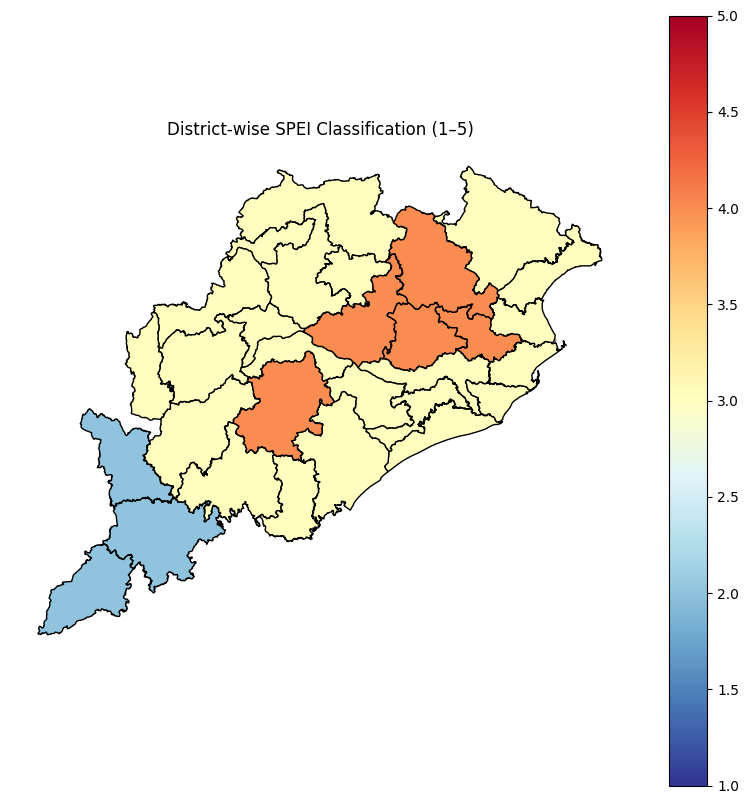


DONE.


In [37]:
# =============================================================================
# DISTRICT-WISE SPEI ANALYSIS + 1–5 CLASSIFICATION
# OUTPUT: CONSOLE + SHAPEFILE + CSV + MAP
# =============================================================================

import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# =============================================================================
# INPUT FILES
# =============================================================================

RASTER_PATH = Path("outputs") / "SPEI4_2024_09.tif"
DISTRICT_FILE = Path("district.geojson")  # change if needed

# =============================================================================
# OUTPUT FILES
# =============================================================================

OUTPUT_SHP = Path("outputs") / "district_spei_2024_09.shp"
OUTPUT_CSV = Path("outputs") / "district_spei_2024_09.csv"
OUTPUT_PNG = Path("outputs") / "district_spei_2024_09.png"

# =============================================================================
# LOAD DISTRICTS
# =============================================================================

gdf = gpd.read_file(DISTRICT_FILE)

# =============================================================================
# CRS ALIGNMENT
# =============================================================================

with rasterio.open(RASTER_PATH) as src:
    raster_crs = src.crs

if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

# =============================================================================
# ZONAL STATISTICS (MEAN SPEI PER DISTRICT)
# =============================================================================

stats = zonal_stats(
    gdf,
    str(RASTER_PATH),
    stats=["mean"],
    nodata=np.nan,
    all_touched=True
)

gdf["spei_mean"] = [s["mean"] for s in stats]
gdf["spei_mean"] = gdf["spei_mean"].fillna(0)

# =============================================================================
# 1–5 CLASSIFICATION (DROUGHT SEVERITY SCALE)
# =============================================================================

def classify_spei(x):
    if x <= -2:
        return 5   # Extreme drought
    elif -2 < x <= -1:
        return 4   # Severe drought
    elif -1 < x <= 0:
        return 3   # Moderate drought
    elif 0 < x < 1:
        return 2   # Normal to wet
    else:
        return 1   # Wet

gdf["spei_class"] = gdf["spei_mean"].apply(classify_spei)

# =============================================================================
# CONSOLE OUTPUT
# =============================================================================

print("\n==============================")
print("DISTRICT SPEI CLASSIFICATION")
print("==============================\n")

for idx, row in gdf.iterrows():
    name = str(row.get("NAME", row.get("district", idx)))
    print(f"{name:<25} -> Class {row['spei_class']} | SPEI {row['spei_mean']:.2f}")

# =============================================================================
# SAVE SHAPEFILE
# =============================================================================

gdf.to_file(OUTPUT_SHP)
print("\nShapefile saved:", OUTPUT_SHP)

# =============================================================================
# SAVE CSV
# =============================================================================

gdf.drop(columns="geometry").to_csv(OUTPUT_CSV, index=False)
print("CSV saved:", OUTPUT_CSV)

# =============================================================================
# PLOT MAP
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf.plot(
    column="spei_class",
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    edgecolor="black",
    vmin=1,
    vmax=5
)

ax.set_title("District-wise SPEI Classification (1–5)")
ax.axis("off")

plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")

print("Map saved:", OUTPUT_PNG)

plt.show()

print("\nDONE.")